# 📈 Financial Time Series Analysis

This notebook performs a comprehensive analysis of major financial assets using historical market data. We explore price trends, returns, risk metrics, correlations, and anomalies to derive actionable investment insights.

**Assets Analyzed:** Apple (AAPL) · NVIDIA (NVDA) · S&P 500 ETF (SPY) · Gold ETF (GLD) · Bitcoin (BTC-USD)  
**Period:** January 2021 – January 2026  
**Data Source:** Yahoo Finance via `yfinance`

---

## 📦 1. Importing Libraries

In [36]:
#Data Manipulation
import numpy as np
import pandas as pd

#Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Financial Data
import yfinance as yf

---

## 📥 2. Loading the Dataset

We download 5 years of historical OHLCV (Open, High, Low, Close, Volume) data for all five assets using the `yfinance` API. The dataset spans from **January 2021 to January 2026**.

In [3]:
# List of assets to analyze
assets = ['AAPL', 'NVDA', 'SPY', 'GLD', 'BTC-USD']
# Download 5 years of historical market data
data = yf.download(
    assets,
    start='2021-01-01',
    end='2026-01-01'
)
# Display first few rows
data.head()

[*********************100%***********************]  5 of 5 completed


Price            Close                                                   \
Ticker            AAPL       BTC-USD         GLD       NVDA         SPY   
Date                                                                      
2021-01-01         NaN  29374.152344         NaN        NaN         NaN   
2021-01-02         NaN  32127.267578         NaN        NaN         NaN   
2021-01-03         NaN  32782.023438         NaN        NaN         NaN   
2021-01-04  125.740868  31971.914062  182.330002  13.060794  343.319061   
2021-01-05  127.295471  33992.429688  182.869995  13.350873  345.683655   

Price             High                                                   ...  \
Ticker            AAPL       BTC-USD         GLD       NVDA         SPY  ...   
Date                                                                     ...   
2021-01-01         NaN  29600.626953         NaN        NaN         NaN  ...   
2021-01-02         NaN  33155.117188         NaN        NaN         NaN  ...   
2021-01-03         NaN  34608.558594         NaN        NaN         NaN  ...   
2021-01-04  129.821783  33440.218750  182.399994  13.597628  349.519083  ...   
2021-01-05  128.004784  34437.589844  183.210007  13.389467  346.772860  ...   

Price             Open                                                   \
Ticker            AAPL       BTC-USD         GLD       NVDA         SPY   
Date                                                                      
2021-01-01         NaN  28994.009766         NaN        NaN         NaN   
2021-01-02         NaN  29376.455078         NaN        NaN         NaN   
2021-01-03         NaN  32129.408203         NaN        NaN         NaN   
2021-01-04  129.734338  32810.949219  181.970001  13.051581  349.388739   
2021-01-05  125.235584  31977.041016  182.869995  13.047099  342.676757   

Price            Volume                                                     
Ticker             AAPL      BTC-USD         GLD         NVDA          SPY  
Date                                                                        
2021-01-01          NaN  40730301359         NaN          NaN          NaN  
2021-01-02          NaN  67865420765         NaN          NaN          NaN  
2021-01-03          NaN  78665235202         NaN          NaN          NaN  
2021-01-04  143301900.0  81163475344  14331400.0  560640000.0  110210800.0  
2021-01-05   97664900.0  67547324782  12718800.0  322760000.0   66426200.0  

[5 rows x 25 columns]

---

## 🔍 3. Exploratory Data Analysis (EDA)

Before any analysis, we inspect the dataset's structure, dimensions, data types, and missing values. This step ensures data quality and informs our cleaning strategy.

In [4]:
# Check dataset dimensions
data.shape

# Check column structure
data.columns

# Check data types and non-null counts
data.info()

# Check missing values
data.isnull().sum()

# Sort missing values from highest to lowest
data.isnull().sum().sort_values(ascending=False)

<class 'pandas.DataFrame'>
DatetimeIndex: 1826 entries, 2021-01-01 to 2025-12-31
Freq: D
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, AAPL)      1255 non-null   float64
 1   (Close, BTC-USD)   1826 non-null   float64
 2   (Close, GLD)       1255 non-null   float64
 3   (Close, NVDA)      1255 non-null   float64
 4   (Close, SPY)       1255 non-null   float64
 5   (High, AAPL)       1255 non-null   float64
 6   (High, BTC-USD)    1826 non-null   float64
 7   (High, GLD)        1255 non-null   float64
 8   (High, NVDA)       1255 non-null   float64
 9   (High, SPY)        1255 non-null   float64
 10  (Low, AAPL)        1255 non-null   float64
 11  (Low, BTC-USD)     1826 non-null   float64
 12  (Low, GLD)         1255 non-null   float64
 13  (Low, NVDA)        1255 non-null   float64
 14  (Low, SPY)         1255 non-null   float64
 15  (Open, AAPL)       1255 non-null   float64
 16  (Open, BT

Price   Ticker 
Close   AAPL       571
        GLD        571
        NVDA       571
        SPY        571
High    AAPL       571
        NVDA       571
        GLD        571
Low     AAPL       571
High    SPY        571
Volume  GLD        571
        NVDA       571
Low     GLD        571
        NVDA       571
Open    AAPL       571
Low     SPY        571
Open    NVDA       571
        GLD        571
Volume  SPY        571
        AAPL       571
Open    SPY        571
Close   BTC-USD      0
High    BTC-USD      0
Low     BTC-USD      0
Open    BTC-USD      0
Volume  BTC-USD      0
dtype: int64

---

## 💲 4. Extracting Closing Prices

We isolate the **Closing Price** column for each asset — the most commonly used price in financial analysis, representing the final traded price of the day.

In [5]:
# Create a dataframe containing only closing prices
close_prices = data['Close']

# Display first few rows
close_prices.head()

Ticker,AAPL,BTC-USD,GLD,NVDA,SPY
Date,,,,,
2021-01-01,NaN,29374.152344,NaN,NaN,NaN
2021-01-02,NaN,32127.267578,NaN,NaN,NaN
2021-01-03,NaN,32782.023438,NaN,NaN,NaN
2021-01-04,125.740868,31971.914062,182.330002,13.060794,343.319061
2021-01-05,127.295471,33992.429688,182.869995,13.350873,345.683655


### 4.1 Validating the Closing Prices DataFrame

A quick check to confirm the shape, missing value count, and data types before we proceed to cleaning.

In [6]:
# Check shape
close_prices.shape

# Check missing values
close_prices.isnull().sum()

# Dataset summary
close_prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1826 entries, 2021-01-01 to 2025-12-31
Freq: D
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   AAPL     1255 non-null   float64
 1   BTC-USD  1826 non-null   float64
 2   GLD      1255 non-null   float64
 3   NVDA     1255 non-null   float64
 4   SPY      1255 non-null   float64
dtypes: float64(5)
memory usage: 85.6 KB


---

## 🧹 5. Data Cleaning

We drop any rows where **at least one asset has a missing value** to ensure all comparisons and calculations are performed on a consistent, aligned dataset.

> **Note:** Differences in trading calendars (e.g., crypto markets trade 24/7 while equities follow NYSE hours) can introduce gaps. Dropping rows with any `NaN` resolves these misalignments.

In [7]:
# Remove dates where any asset has missing values
analysis_df = close_prices.dropna()

# Verify shape
analysis_df.shape

# Verify no missing values remain
analysis_df.isnull().sum()

# Display first few rows
analysis_df.head()

Ticker,AAPL,BTC-USD,GLD,NVDA,SPY
Date,,,,,
2021-01-04,125.740868,31971.914062,182.330002,13.060794,343.319061
2021-01-05,127.295471,33992.429688,182.869995,13.350873,345.683655
2021-01-06,123.010506,36824.363281,179.899994,12.563801,347.750488
2021-01-07,127.208023,39371.042969,179.479996,13.290367,352.917053
2021-01-08,128.306000,40797.609375,173.339996,13.223390,354.927887


---

## 📊 6. Visualizing Asset Prices

### 6.1 Actual Closing Prices

We plot the raw closing prices of all five assets over time. Note that assets with different price scales (e.g., BTC-USD vs. SPY) make direct visual comparison difficult — this is addressed by normalization in the next step.

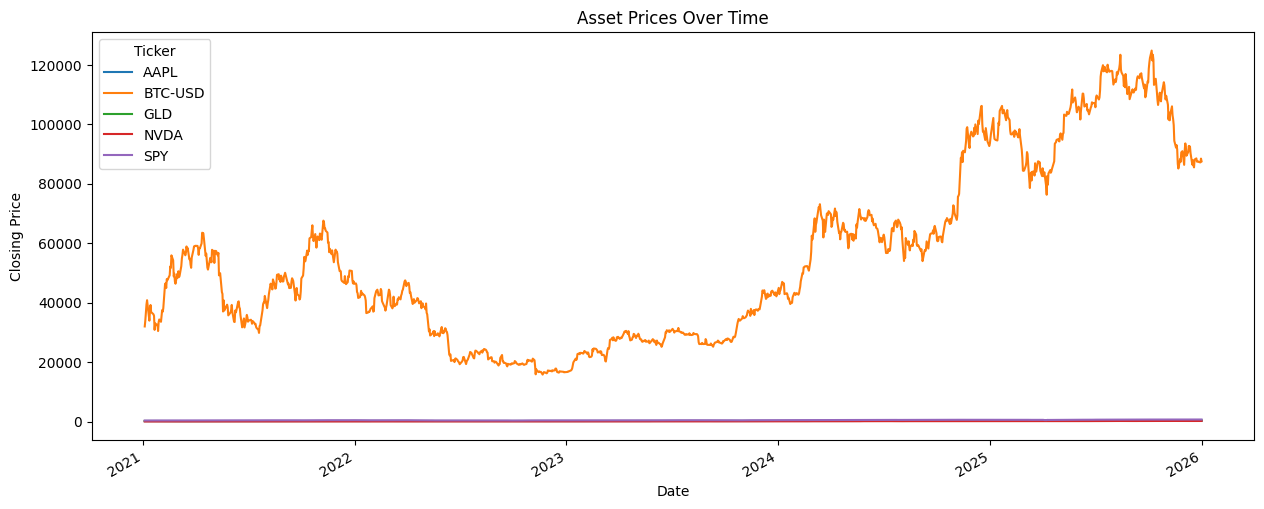

In [8]:
# Plot actual closing prices

analysis_df.plot(figsize=(15,6))
plt.title("Asset Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

### 6.2 Normalizing Prices (Base = 100)

To make a fair **apples-to-apples comparison**, we normalize all assets to a starting value of **100**. This lets us see which asset delivered the best relative performance regardless of its absolute price.

In [9]:
# Normalize all assets to start at 100
normalized_df = analysis_df / analysis_df.iloc[0] * 100

# Display first few rows
normalized_df.head()

Ticker,AAPL,BTC-USD,GLD,NVDA,SPY
Date,,,,,
2021-01-04,100.000000,100.000000,100.000000,100.000000,100.000000
2021-01-05,101.236355,106.319658,100.296163,102.220991,100.688745
2021-01-06,97.828580,115.177225,98.667247,96.194771,101.290761
2021-01-07,101.166809,123.142590,98.436897,101.757728,102.795648
2021-01-08,102.040015,127.604526,95.069377,101.244915,103.381352


### 6.3 Normalized Performance Chart

Each asset starts at 100. A value of 200 means the asset **doubled** from its starting price; a value of 50 means it **lost half** its value.

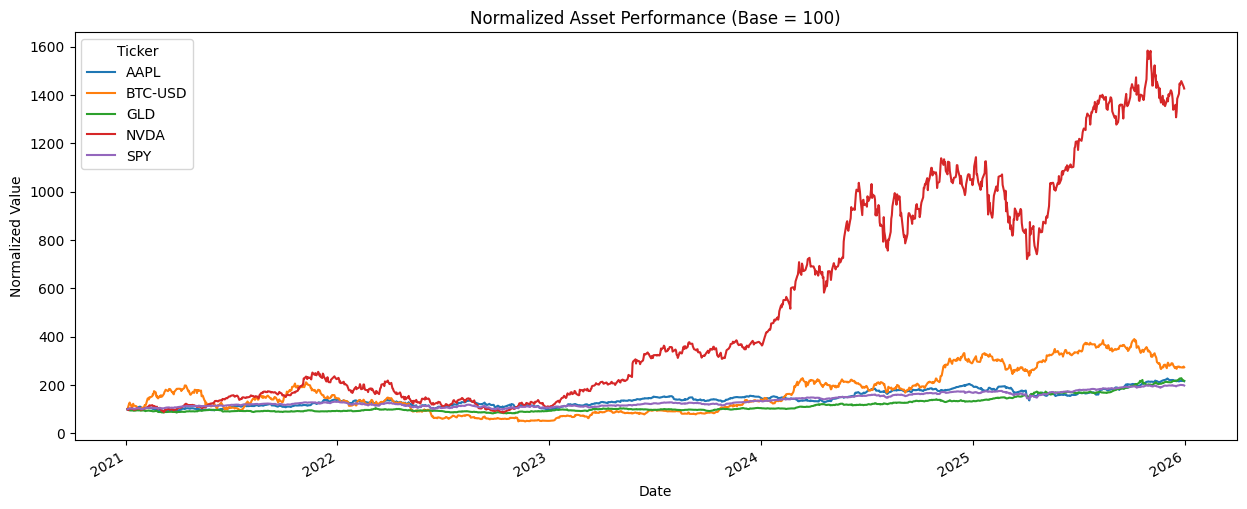

In [10]:
# Compare performance of equal investments

normalized_df.plot(figsize=(15,6))
plt.title("Normalized Asset Performance (Base = 100)")
plt.xlabel("Date")
plt.ylabel("Normalized Value")
plt.show()

---

## 📉 7. Daily Returns

**Daily returns** measure the percentage change in price from one trading day to the next. They are the foundation of virtually all risk and performance metrics in quantitative finance.

$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}}$$

In [11]:
# Calculate day-to-day percentage changes
daily_returns = analysis_df.pct_change()

# Display first few rows
daily_returns.head()

Ticker,AAPL,BTC-USD,GLD,NVDA,SPY
Date,,,,,
2021-01-04,NaN,NaN,NaN,NaN,NaN
2021-01-05,0.012364,0.063197,0.002962,0.022210,0.006887
2021-01-06,-0.033662,0.083311,-0.016241,-0.058953,0.005979
2021-01-07,0.034123,0.069157,-0.002335,0.057830,0.014857
2021-01-08,0.008631,0.036234,-0.034210,-0.005040,0.005698


### 7.1 Validating Daily Returns

We verify the shape and confirm that only one row of `NaN` exists (the first row has no previous day to compare against).

In [12]:
# Check dimensions
daily_returns.shape

# Check missing values
daily_returns.isnull().sum()

# Dataset summary
daily_returns.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1255 entries, 2021-01-04 to 2025-12-31
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   AAPL     1254 non-null   float64
 1   BTC-USD  1254 non-null   float64
 2   GLD      1254 non-null   float64
 3   NVDA     1254 non-null   float64
 4   SPY      1254 non-null   float64
dtypes: float64(5)
memory usage: 58.8 KB


---

## ⚖️ 8. Risk vs. Return Analysis

A core principle in finance: **higher potential returns come with higher risk**. Here we quantify both dimensions for each asset.

### 8.1 Average Daily Return

The mean daily return gives us each asset's **expected gain per trading day**.

In [13]:
# Calculate average daily return for each asset

avg_returns = daily_returns.mean()
avg_returns

Ticker
AAPL       0.000767
BTC-USD    0.001488
GLD        0.000668
NVDA       0.002657
SPY        0.000603
dtype: float64

### 8.2 Volatility (Standard Deviation of Returns)

Volatility measures how much daily returns fluctuate. A **higher standard deviation** indicates greater uncertainty — the asset swings more wildly, both up and down.

In [14]:
# Calculate standard deviation of returns
# This represents risk (volatility)

volatility = daily_returns.std()
volatility

Ticker
AAPL       0.017552
BTC-USD    0.036992
GLD        0.009837
NVDA       0.032898
SPY        0.010779
dtype: float64

### 8.3 Risk-Return Summary Table

In [15]:
# Combine return and risk metrics

risk_return = pd.DataFrame({
    'Average Return': avg_returns,
    'Volatility': volatility
})
risk_return

,Average Return,Volatility
Ticker,,
AAPL,0.000767,0.017552
BTC-USD,0.001488,0.036992
GLD,0.000668,0.009837
NVDA,0.002657,0.032898
SPY,0.000603,0.010779


### 8.4 Ranking Assets by Return

In [16]:
# Rank assets by return

risk_return.sort_values(
    by='Average Return',
    ascending=False
)

,Average Return,Volatility
Ticker,,
NVDA,0.002657,0.032898
BTC-USD,0.001488,0.036992
AAPL,0.000767,0.017552
GLD,0.000668,0.009837
SPY,0.000603,0.010779


### 8.5 Complete Risk-Return Table (Sorted)

The table below consolidates average return and volatility, sorted by return — making it easy to identify the best and worst performers.

In [17]:
# Calculate average daily return
avg_returns = daily_returns.mean()

# Calculate volatility (risk)
volatility = daily_returns.std()

# Create risk-return table
risk_return = pd.DataFrame({
    'Average Return': avg_returns,
    'Volatility': volatility
})
# Sort by return
risk_return.sort_values(
    by='Average Return',
    ascending=False
)

,Average Return,Volatility
Ticker,,
NVDA,0.002657,0.032898
BTC-USD,0.001488,0.036992
AAPL,0.000767,0.017552
GLD,0.000668,0.009837
SPY,0.000603,0.010779


### 8.6 Risk vs. Return Scatter Plot

Each point represents one asset. Assets in the **upper-left** offer high return for low risk (ideal). Assets in the **lower-right** offer low return for high risk (least desirable).

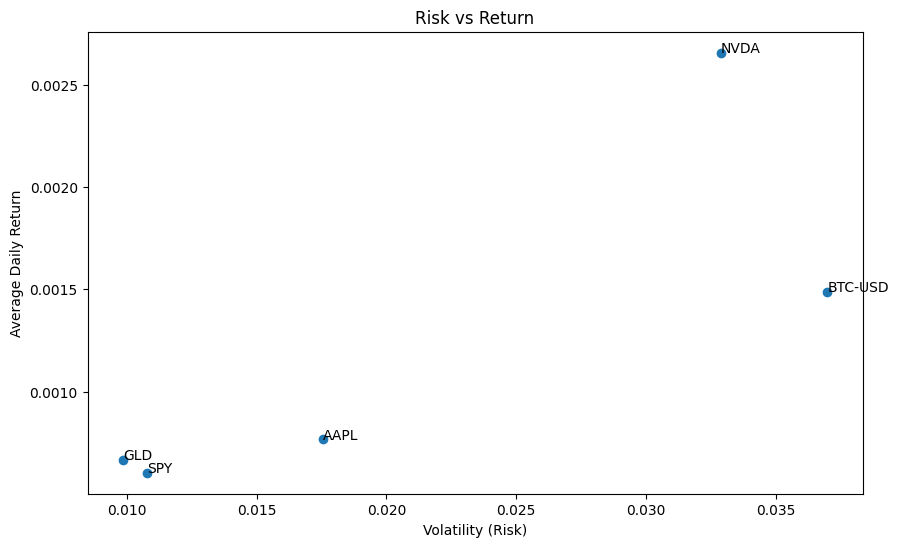

In [19]:
plt.figure(figsize=(10,6))
# Plot risk vs return points
plt.scatter(
    risk_return['Volatility'],
    risk_return['Average Return']
)
# Add asset names next to each point
for asset in risk_return.index:
    plt.annotate(
        asset,
        (
            risk_return.loc[asset, 'Volatility'],
            risk_return.loc[asset, 'Average Return']
        )
    )
plt.title('Risk vs Return')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Average Daily Return')
plt.show()

---

## 🔗 9. Correlation Analysis

**Correlation** measures how similarly two assets move day-to-day.

| Value | Interpretation |
|-------|----------------|
| `+1.0` | Perfect positive correlation — move in lockstep |
| `0.0` | No relationship |
| `-1.0` | Perfect negative correlation — move in opposite directions |

> **Portfolio insight:** Assets with low or negative correlation reduce overall portfolio risk through diversification.

In [20]:
# Calculate correlation between daily returns
corr_matrix = daily_returns.corr()
# Display correlation matrix
corr_matrix

Ticker,AAPL,BTC-USD,GLD,NVDA,SPY
Ticker,,,,,
AAPL,1.000000,0.248296,0.071100,0.519852,0.758225
BTC-USD,0.248296,1.000000,0.070073,0.299393,0.367152
GLD,0.071100,0.070073,1.000000,0.066761,0.125467
NVDA,0.519852,0.299393,0.066761,1.000000,0.698911
SPY,0.758225,0.367152,0.125467,0.698911,1.000000


### 9.1 Correlation Heatmap

The heatmap uses a **coolwarm** color scale — deep red indicates high positive correlation, deep blue indicates negative correlation.

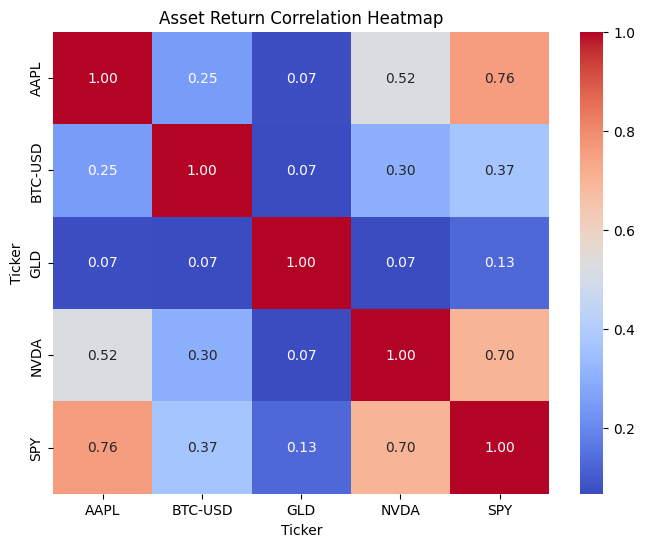

In [21]:
plt.figure(figsize=(8,6))
# Draw correlation heatmap
sns.heatmap(
    corr_matrix,
    annot=True,      # Show correlation values
    cmap='coolwarm', # Color scheme
    fmt='.2f'        # Display 2 decimal places
)
# Add title
plt.title('Asset Return Correlation Heatmap')
plt.show()

---

## 📐 10. Moving Average Analysis (NVDA)

Moving averages **smooth out price noise** and help identify the underlying trend direction.

| Moving Average | Window | Purpose |
|----------------|--------|---------|
| **MA-50** | 50 days | Short-to-medium term trend |
| **MA-200** | 200 days | Long-term trend / major support-resistance |

> **Golden Cross:** MA-50 crosses **above** MA-200 → bullish signal.  
> **Death Cross:** MA-50 crosses **below** MA-200 → bearish signal.

We apply this analysis to **NVIDIA (NVDA)** — one of the most volatile and high-returning assets in our portfolio.

In [22]:
# Calculate 50-day moving average
nvda_ma50 = analysis_df['NVDA'].rolling(window=50).mean()

# Calculate 200-day moving average
nvda_ma200 = analysis_df['NVDA'].rolling(window=200).mean()

### 10.1 NVDA Price with 50-Day and 200-Day Moving Averages

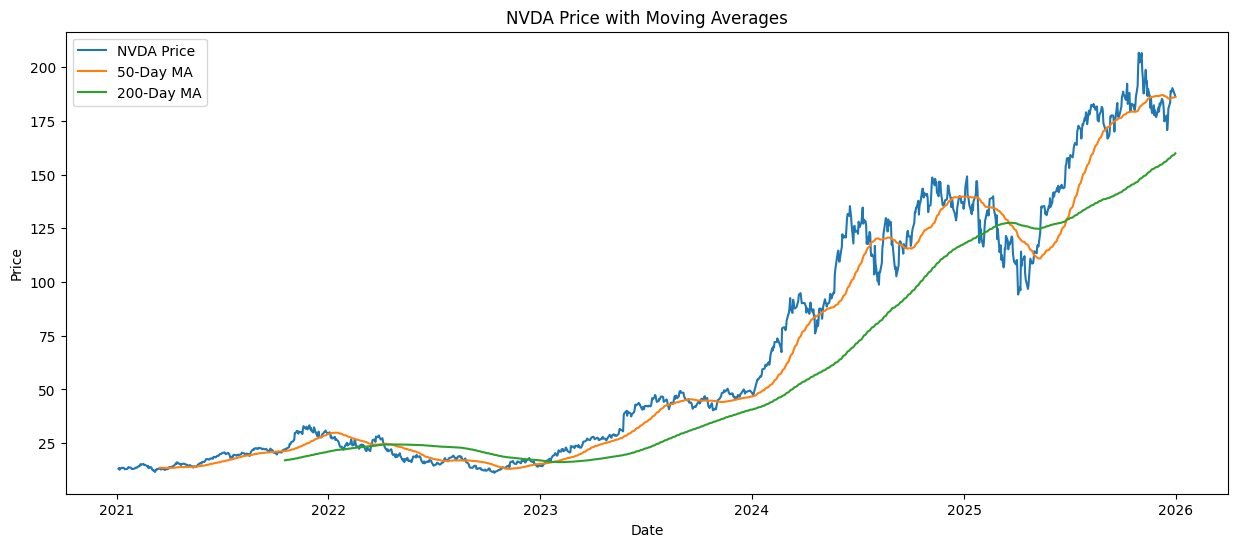

In [23]:
plt.figure(figsize=(15,6))
# Plot NVDA closing price
plt.plot(
    analysis_df.index,
    analysis_df['NVDA'],
    label='NVDA Price'
)
# Plot 50-day moving average
plt.plot(
    analysis_df.index,
    nvda_ma50,
    label='50-Day MA'
)
# Plot 200-day moving average
plt.plot(
    analysis_df.index,
    nvda_ma200,
    label='200-Day MA'
)
plt.title('NVDA Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

---

## 🚨 11. Anomaly Detection in NVDA Returns

We flag **statistically extreme** trading days using the **3-sigma rule** — any daily return more than 3 standard deviations from the mean is classified as an anomaly.

$$\text{Anomaly if: } r_t > \mu + 3\sigma \quad \text{or} \quad r_t < \mu - 3\sigma$$

These events typically correspond to major earnings surprises, macroeconomic shocks, or sudden market events.

In [24]:
# Calculate NVDA mean return
nvda_mean = daily_returns['NVDA'].mean()

# Calculate NVDA volatility
nvda_std = daily_returns['NVDA'].std()

# Define upper anomaly threshold
upper_threshold = nvda_mean + (3 * nvda_std)

# Define lower anomaly threshold
lower_threshold = nvda_mean - (3 * nvda_std)

# Select anomalous days
nvda_anomalies = daily_returns[
    (daily_returns['NVDA'] > upper_threshold) |
    (daily_returns['NVDA'] < lower_threshold)
]
# Display anomalies
nvda_anomalies

Ticker,AAPL,BTC-USD,GLD,NVDA,SPY
Date,,,,,
2021-11-04,-0.003498,-0.024104,0.011341,0.120422,0.004713
2022-11-10,0.088975,0.107425,0.030444,0.143293,0.054955
2023-02-23,0.003291,-0.009978,-0.000530,0.140214,0.005320
2023-05-25,0.006692,0.005369,-0.009618,0.243696,0.008660
2024-02-22,0.011244,-0.010305,0.000427,0.164009,0.020696
2024-04-19,-0.012212,0.005209,0.003132,-0.100046,-0.008728
2024-07-31,0.014991,-0.023893,0.018111,0.128121,0.016255
2025-01-27,0.031780,-0.026062,-0.010405,-0.169682,-0.014145
2025-04-09,0.153288,0.082625,0.036991,0.187227,0.105019


### 11.1 Number of Anomalous Days Detected

In [25]:
# Number of detected anomalies
len(nvda_anomalies)

9

### 11.2 Visualizing Return Anomalies

Red dots mark the days where NVDA's return exceeded the 3-sigma threshold — these are the outlier events worth investigating further.

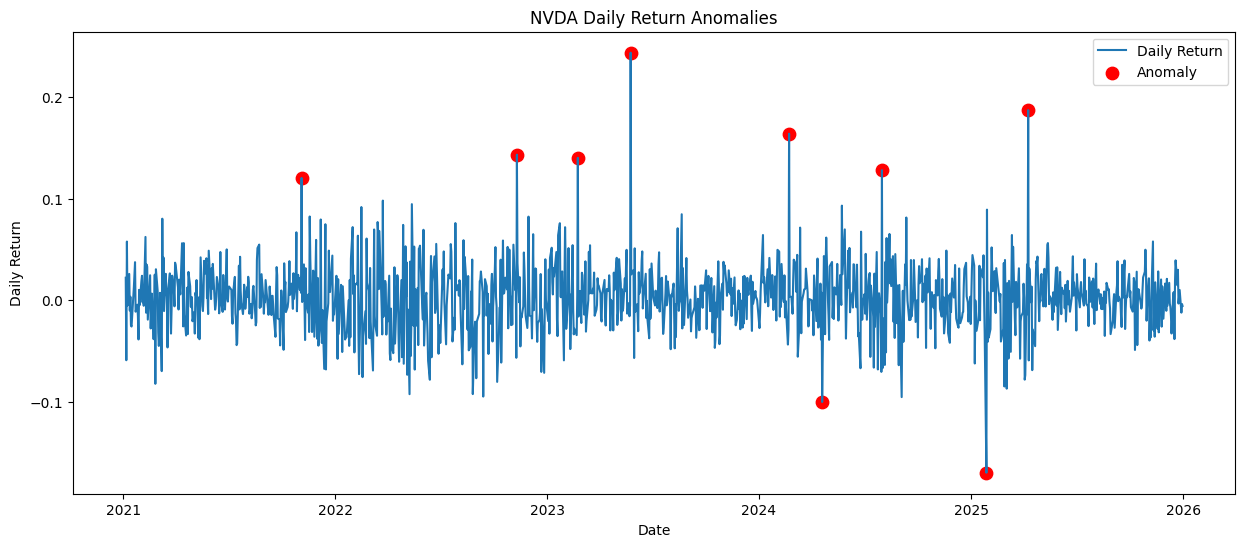

In [27]:
plt.figure(figsize=(15,6))
plt.plot(
    daily_returns.index,
    daily_returns['NVDA'],
    label='Daily Return'
)
# Highlight anomalies
plt.scatter(
    nvda_anomalies.index,
    nvda_anomalies['NVDA'],
    color='red',          # make anomalies stand out
    s=80,                 # larger markers
    label='Anomaly'
)
plt.title('NVDA Daily Return Anomalies')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend()
plt.show()

---

## 🏆 12. Sharpe Ratio

The **Sharpe Ratio** measures return per unit of risk — it is the most widely used metric for comparing investment performance on a risk-adjusted basis.

$$\text{Sharpe Ratio} = \frac{\bar{r}}{\sigma}$$

> A higher Sharpe Ratio means the asset delivered **more return per unit of risk taken**.  
> This simplified version uses mean daily return and daily volatility (no risk-free rate subtracted)."

In [28]:
# Calculate Sharpe Ratio
risk_return['Sharpe Ratio'] = (
    risk_return['Average Return']
    / risk_return['Volatility']
)
# Sort from highest to lowest Sharpe Ratio
risk_return.sort_values(
    by='Sharpe Ratio',
    ascending=False
)

,Average Return,Volatility,Sharpe Ratio
Ticker,,,
NVDA,0.002657,0.032898,0.080755
GLD,0.000668,0.009837,0.067881
SPY,0.000603,0.010779,0.055956
AAPL,0.000767,0.017552,0.043686
BTC-USD,0.001488,0.036992,0.040218


### 12.1 Sharpe Ratio Bar Chart

Assets are sorted from highest to lowest Sharpe Ratio. The best risk-adjusted performer sits at the top.

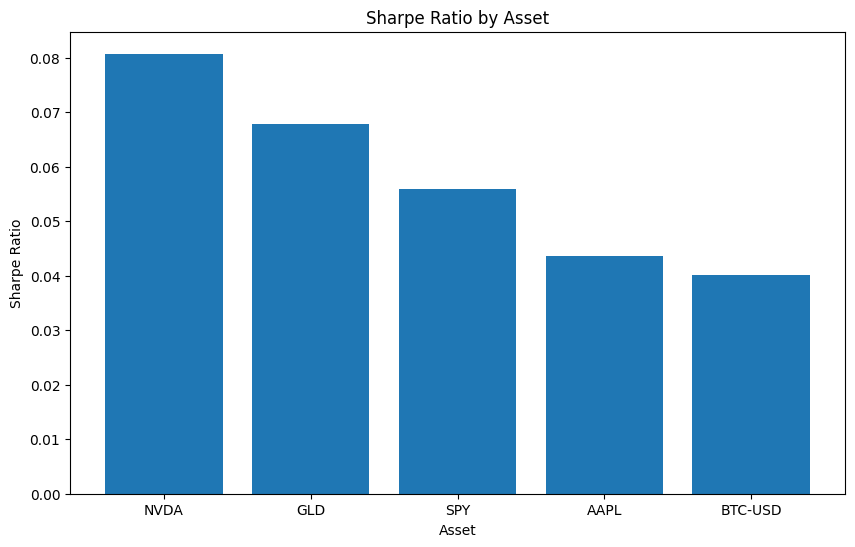

In [29]:
# Sort assets by Sharpe Ratio
sharpe_sorted = risk_return.sort_values(
    by='Sharpe Ratio',
    ascending=False
)
plt.figure(figsize=(10,6))
# Plot Sharpe Ratios
plt.bar(
    sharpe_sorted.index,
    sharpe_sorted['Sharpe Ratio']
)
plt.title('Sharpe Ratio by Asset')
plt.xlabel('Asset')
plt.ylabel('Sharpe Ratio')
plt.show()

---

## 📉 13. Maximum Drawdown

**Maximum Drawdown (MDD)** measures the largest peak-to-trough decline an asset experienced over the analysis period. It is the most important **downside risk** metric.

$$\text{MDD} = \frac{\text{Trough Value} - \text{Peak Value}}{\text{Peak Value}}$$

An MDD of `-0.80` means the asset **lost 80% of its value** from its highest point before recovering. Investors with low risk tolerance should pay close attention to this metric.

In [31]:
cumulative_returns = (1 + daily_returns).cumprod()

### 13.1 Computing Drawdown

In [33]:
running_max = cumulative_returns.cummax()
drawdown = (cumulative_returns - running_max) / running_max
max_drawdown = drawdown.min()
print(max_drawdown)

Ticker
AAPL      -0.333605
BTC-USD   -0.766346
GLD       -0.210328
NVDA      -0.663351
SPY       -0.244964
dtype: float64


### 13.2 Maximum Drawdown Bar Chart

Assets are sorted from worst (most negative) to least severe. The deeper the bar, the more painful the worst historical loss was for that asset.

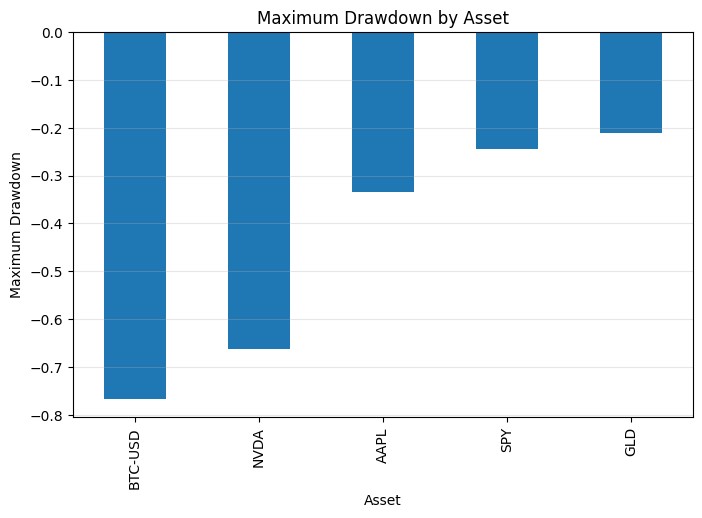

In [34]:
plt.figure(figsize=(8,5))
max_drawdown.sort_values().plot(kind='bar')

plt.title('Maximum Drawdown by Asset')
plt.ylabel('Maximum Drawdown')
plt.xlabel('Asset')
plt.grid(axis='y', alpha=0.3)
plt.show()

### 13.3 Maximum Drawdown — Exact Values

In [35]:
print(max_drawdown.sort_values())

Ticker
BTC-USD   -0.766346
NVDA      -0.663351
AAPL      -0.333605
SPY       -0.244964
GLD       -0.210328
dtype: float64


---

## ✅ 14. Summary & Key Takeaways

| Metric | Best Performer | Worst Performer |
|--------|---------------|-----------------|
| **Total Return** | NVDA | GLD |
| **Volatility (Risk)** | GLD (lowest) | BTC-USD (highest) |
| **Sharpe Ratio** | NVDA | BTC-USD |
| **Maximum Drawdown** | SPY / GLD | BTC-USD |

### Key Insights
- **NVDA** dominated on raw and risk-adjusted returns, driven by the AI boom.
- **BTC-USD** offered extreme upside but came with the highest volatility and deepest drawdown.
- **GLD** served as a stable, low-volatility hedge with modest but consistent returns.
- **SPY** delivered steady market returns with controlled risk — a solid benchmark.
- **Diversification** across these asset classes could reduce portfolio-level risk without sacrificing total return.

---

*Analysis performed using Python · pandas · matplotlib · seaborn · yfinance*